In [2]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmc5/10xpbmc5_symbol.h5ad"
#path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmc5/10xpbmc5_id.h5ad"

In [5]:
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

### Step 1: Prep data

In [7]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
#adata.var.index = adata.var["gene_name"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

# Prep data for cell2sentence 
#adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [8]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref = adata_ref.copy()

# Remove unmapped genes
adata_ref.var.index = adata_ref.var["gene_id"]
#adata_ref.var.index = adata_ref.var["gene_name"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

# Prep data for geneformer 
adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="geneformer")

In [9]:
adata.obs["broad_type"].value_counts()

broad_type
T cells      5334
Monocytes    3204
B cells       960
NK cells      469
Name: count, dtype: int64

In [10]:
adata_ref.obs["broad_type"].value_counts()

broad_type
B cells      800
Monocytes    800
NK cells     800
T cells      800
Name: count, dtype: int64

### Step 2: Create pseudobulk

In [11]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 250,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 300, 
                                             random_state = 42 
                                            )

### Step 3: Create signature matrix

In [12]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata_ref,
                                  sample_col = "batch", # sample id column
                                  cell_type_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

In [13]:
#pseudo_bulk.to_csv("../scripts/pseudobulk_data_10xpbmc5_symbol.csv")

### Step 4: Extract Embeddings

In [14]:
from embeddings import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [15]:
from deconvolution import *

<h4 style="color:blue">Geneformer</h4>

In [16]:
sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/geneformer_lora_adapter", #"ctheodoris/Geneformer",
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████| 1/1 [00:00<00:00, 27.74it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading Geneformer model...


Loading adapter weights from /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/geneformer_lora_adapter led to unexpected keys not found in the model:  ['classifier.bias', 'classifier.weight']. 
CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/geneformer_lora_adapter", #"ctheodoris/Geneformer",
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


Loading adapter weights from /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/geneformer_lora_adapter led to unexpected keys not found in the model:  ['classifier.bias', 'classifier.weight']. 
CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/5 [00:00<?, ?it/s]

In [18]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_gf_embed.T, 
                            normalize = True)

Using 1152 common features.
Running deconvolution...


In [19]:
#cell_prop_pred.to_csv("../results/pbmc10x/LoRAGeneformer_estimated_proportions.csv")

In [26]:
#cell_prop.to_csv("../results/pbmc10x/pseudobulk_true_proportions.csv.csv")

<h4 style="color:blue">PCA</h4>

In [27]:
# Extract embeddings 
bulk_sig_mat_pc = extract_components(bulk_df = pseudo_bulk,
                                     sig_mat = sig_mat,
                                     mode = "pca",
                                     transform = True)

bulk_pc = bulk_sig_mat_pc["pca_bulk"]
sig_mat_pc = bulk_sig_mat_pc["sig_pca"]

In [28]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T, 
                            signature_df = sig_mat_pc.T, 
                            normalize = True)

In [29]:
#cell_prop_pred.to_csv("../results/pbmc10x/PCA_estimated_proportions.csv")

<h4 style="color:blue">scVI</h4>

In [30]:
sig_mat_scvi_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

In [31]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

In [32]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_scvi_embed.T, 
                            normalize = True)

In [33]:
#cell_prop_pred.to_csv("../results/pbmc10x/scVI_estimated_proportions.csv")

<h4 style="color:blue">Counts</h4>

In [34]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk.T,
                            signature_df = sig_mat.T,
                            normalize = True)

In [35]:
#cell_prop_pred.to_csv("../results/pbmc10x/Counts_estimated_proportions.csv")

<h4 style="color:blue">scGPT</h4>

In [42]:
sig_mat_scgpt_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

In [43]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk,
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

In [44]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_scgpt_embed.T,
                            normalize = True)

In [41]:
#cell_prop_pred.to_csv("../results/pbmc10x/scGPT_estimated_proportions.csv")

<h4 style="color:blue">Cell2Sentence</h4>

In [18]:
sig_mat_c2s_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "c2s", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

In [19]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "c2s",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

In [20]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_c2s_embed.T, 
                            normalize = True)

In [21]:
#cell_prop_pred.to_csv("../results/pbmc10x/C2S_estimated_proportions.csv")

<h4 style="color:blue">CellHermes</h4>

In [18]:
sig_mat_ch_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "cellhermes", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
    delete_temp_files = True)

In [20]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "cellhermes",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
    delete_temp_files = True
)

In [23]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_ch_embed.T, 
                            normalize = True)

In [25]:
#cell_prop_pred.to_csv("../results/pbmc10x/CellHermes_estimated_proportions.csv")

### Step 5: Visualize Results

In [5]:
# Import associated modules
from visualization import *

In [6]:
res_df = load_results(folder_path = '../results/pbmc10x/',
                      ground_truth_file = '../results/pbmc10x/pseudobulk_true_proportions.csv')

# Drop ground truth results 
res_df = res_df[res_df.Model != "pseudobulk"]

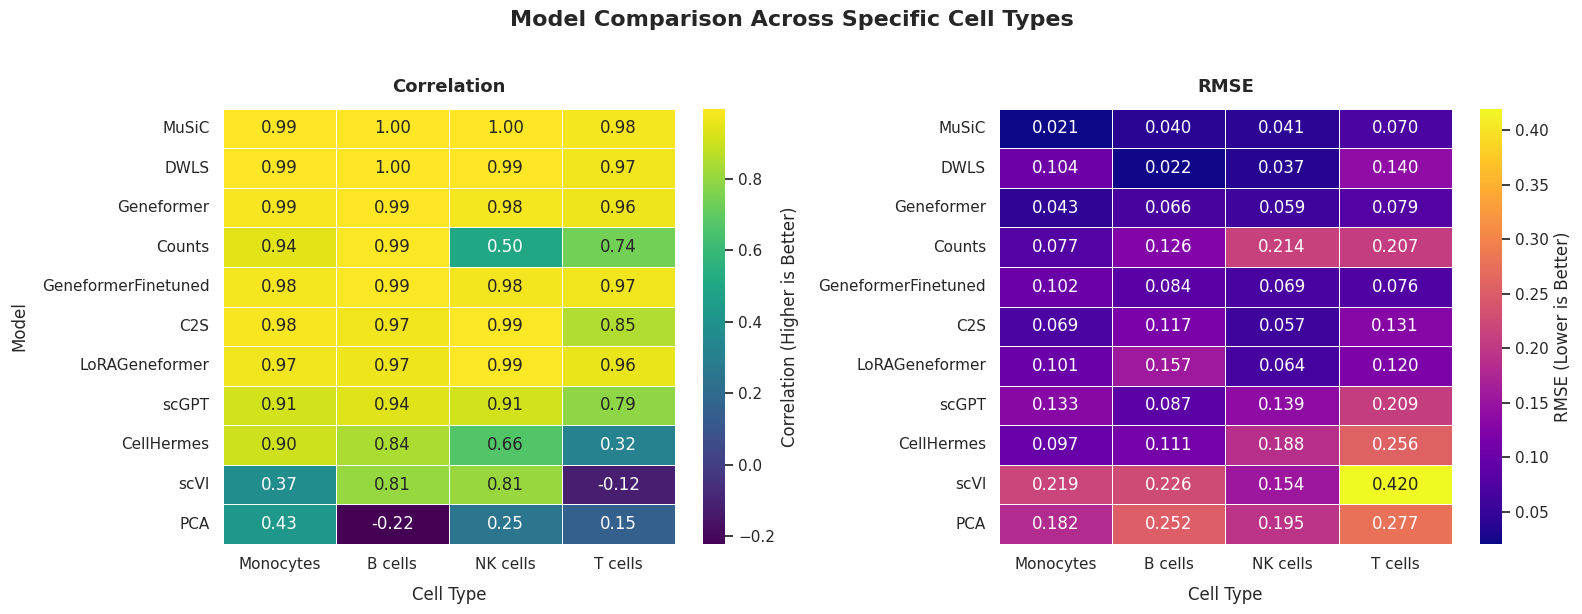

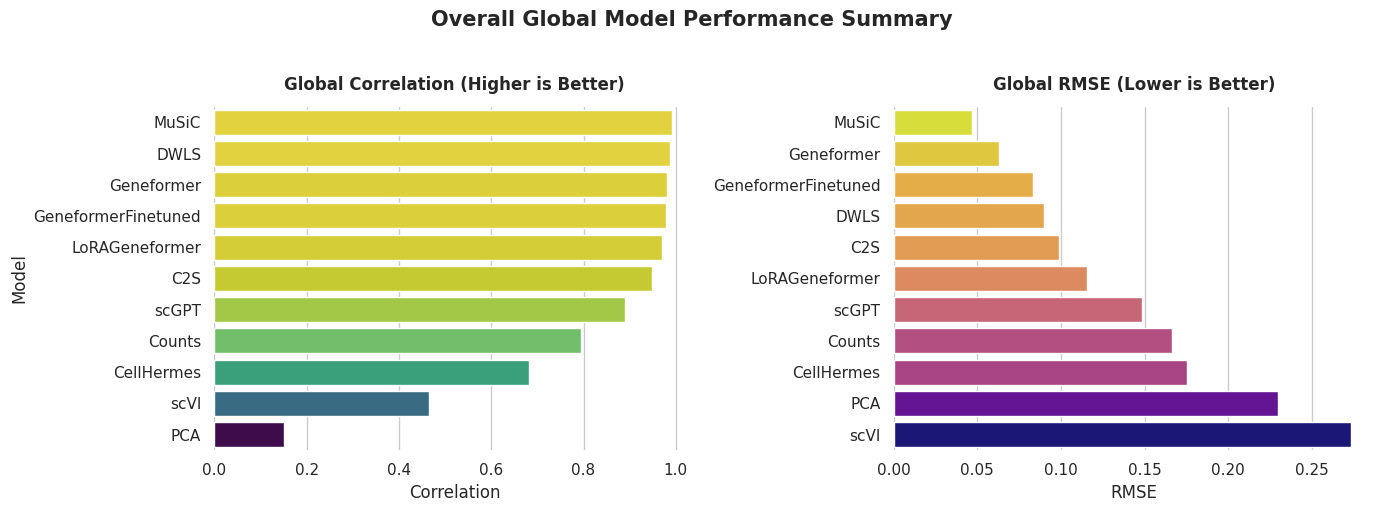

In [7]:
# Remove global correlations/RMSEs
res_df_cell_type = res_df[res_df['CellType'] != 'Global'].copy()
res_df_global = res_df[res_df['CellType'] == 'Global'].copy()

# Plot
plot_cell_type_heatmaps(res_df_cell_type)
plot_global_comparison(res_df_global)